In [ ]:
# -Data Exploration
# Load and inspect data
import pandas as pd
import numpy as np


df = pd.read_csv('GLODAPv2.2023_Atlantic_Ocean.csv')
print('YAYYY,dataset uploaded')

print("First 5 rows:")
print(df.head())


print("Check for null values")
print(df.isnull().sum())
print("Summary Statistics:")
print(df.describe())

pd.set_option('display.max_columns', None)
print(df)

row_count = len(df)

# 1. Select the columns you actually care about for DEOXY.AI
key_cols = ['G2year','G2month', 'G2latitude', 'G2longitude', 'G2depth',
            'G2temperature', 'G2salinity', 'G2oxygen',
            'G2nitrate', 'G2phosphate', 'G2silicate']
df_subset = df[key_cols].copy()

# 2. Convert the fake numbers (-9999) into official missing values (NaN)
df_subset.replace(-9999.0, np.nan, inplace=True)

# 3. Drop any row that has a missing value in those columns
df_clean = df_subset.dropna()

# 4. Print the final answer!
print(f"Total Raw Rows: {len(df):,}")
print(f"Total USEABLE Rows: {len(df_clean):,}")
print(f"Percentage of useable data: {(len(df_clean)/len(df))*100:.1f}%")

YAYYY,dataset uploaded
First 5 rows:
     G2expocode  G2cruise  G2station  G2region  G2cast  G2year  G2month  \
0  06AQ19860627       2.0      234.0       1.0     1.0  1986.0      7.0   
1  06AQ19860627       2.0      234.0       1.0     3.0  1986.0      7.0   
2  06AQ19860627       2.0      234.0       1.0     1.0  1986.0      7.0   
3  06AQ19860627       2.0      234.0       1.0     1.0  1986.0      7.0   
4  06AQ19860627       2.0      234.0       1.0     1.0  1986.0      7.0   

   G2day  G2hour  G2minute  ...  G2tocf   G2doc  G2docf   G2don  G2donf  \
0   17.0     0.0       0.0  ...     9.0 -9999.0     9.0 -9999.0     9.0   
1   17.0     0.0       0.0  ...     9.0 -9999.0     9.0 -9999.0     9.0   
2   17.0     0.0       0.0  ...     9.0 -9999.0     9.0 -9999.0     9.0   
3   17.0     0.0       0.0  ...     9.0 -9999.0     9.0 -9999.0     9.0   
4   17.0     0.0       0.0  ...     9.0 -9999.0     9.0 -9999.0     9.0   

    G2tdn  G2tdnf  G2chla  G2chlaf  \
0 -9999.0     9.0 -9999

In [ ]:
# Identifiying Key Columns

df_subset = df[['G2year','G2month', 'G2latitude', 'G2longitude', 'G2depth','G2temperature','G2salinity','G2oxygen','G2nitrate','G2phosphate','G2silicate']]

In [ ]:
# Checking For Missing Data
print(df_subset.isnull().sum())
(df_subset['G2year'] == -9999).sum()
(df_subset['G2month'] == -9999).sum()
(df_subset['G2latitude'] == -9999).sum()
(df_subset['G2longitude'] == -9999).sum()
(df_subset['G2depth'] == -9999).sum()
(df_subset['G2temperature'] == -9999).sum()
(df_subset['G2salinity'] == -9999).sum()
(df_subset['G2oxygen'] == -9999).sum()
(df_subset['G2nitrate'] == -9999).sum()
(df_subset['G2phosphate'] == -9999).sum()
(df_subset['G2silicate'] == -9999).sum()


G2year           0
G2month          0
G2latitude       0
G2longitude      0
G2depth          0
G2temperature    0
G2salinity       0
G2oxygen         0
G2nitrate        0
G2phosphate      0
G2silicate       0
dtype: int64


np.int64(134570)

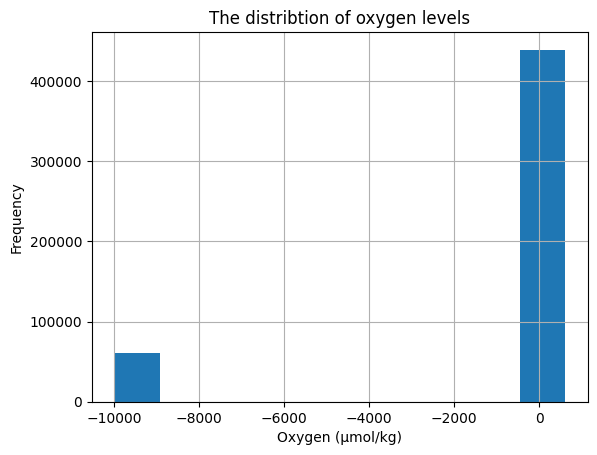

In [ ]:
# Visualise Oxygen Distribution
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df_subset['G2oxygen'].hist()
plt.xlabel('Oxygen (µmol/kg)')
plt.ylabel('Frequency')
plt.title('The distribtion of oxygen levels')
plt.show()

In [ ]:

# Removing invalid values from the columns we need, including the location and date/time.
selected_cols = ['G2oxygen', 'G2temperature', 'G2salinity', 'G2depth', 'G2nitrate', 'G2phosphate', 'G2silicate', 'G2latitude','G2longitude', 'G2year', 'G2month']

#Copy prior before modification so originial isnt touched.

df_subset = df[selected_cols].copy()

#Replacing the -9999 missing value with NaN before next step

df_subset = df_subset.replace(-9999, np.nan)


print("Missing values per column.")
print(df_subset.isnull().sum())

df_clean = df_subset.dropna()
print(f"Rows after dropna: {len(df_clean):,}")

print("Duplicate rows before removal:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("Cleaned dataset shape:", df_clean.shape)

print(f"Percentage of captured rows: {(len(df_clean) / len(df_subset)) * 100: .1f}%")

Missing values per column.
G2oxygen          60943
G2temperature      4066
G2salinity        15646
G2depth             110
G2nitrate        150405
G2phosphate      185090
G2silicate       134570
G2latitude            0
G2longitude           0
G2year                0
G2month               0
dtype: int64
Rows after dropna: 260,161
Duplicate rows before removal: 2204
Duplicate rows after removal: 0
Cleaned dataset shape: (257957, 11)
Percentage of captured rows:  51.6%


In [ ]:
# Check cleaned data

print("=== Cleaned Data Info")
print(df_clean.head(10))
print("\n")
print(df_clean.describe())

#Oxygen dstribution in clean data:
print("\n=== Oxygen Statistics ===")
print(f"Min: {df_clean['G2oxygen'].min():.2f} µmol/kg")
print(f"Max: {df_clean['G2oxygen'].max():.2f} µmol/kg")
print(f"Mean: {df_clean['G2oxygen'].mean():.2f} µmol/kg")
print(f"Median: {df_clean['G2oxygen'].median():.2f} µmol/kg")

# Count how many hypoxic measurements you have (oxygen <60):
hypoxic_count = (df_clean['G2oxygen']< 60).sum()
print(f"\nHypoxic measurements (<60 µmol/kg): {hypoxic_count} ({(hypoxic_count/len(df_clean))*100:.1f}%)")




=== Cleaned Data Info
    G2oxygen  G2temperature  G2salinity  G2depth  G2nitrate  G2phosphate  \
17    345.82         -1.282      34.147      9.0     25.577       1.9426   
18    345.38         -1.357      34.158     20.0     25.576       1.9426   
20    345.82         -1.413      34.170     33.0     25.576       1.9327   
21    338.40         -1.431      34.171     53.0     25.576       1.9426   
22    344.50         -1.477      34.185     72.0     25.473       1.9326   
24    344.94         -1.510      34.185     93.0     25.268       1.9326   
25    346.20         -1.481      34.187    102.0     29.899       1.9326   
26    320.10         -1.089      34.273    143.0     30.225       2.0029   
28    235.32         -0.033      34.570    193.0     33.040       2.2552   
29    208.35          0.634      34.668    291.0     32.617       2.2759   

    G2silicate  G2latitude  G2longitude  G2year  G2month  
17      69.280     -58.483        -0.99  1986.0      7.0  
18      70.070     -58.

In [ ]:
# Save your cleaned Dataset
df_clean.to_csv('GLODAP_clean.csv', index=False)
print("Cleaned data saved to 'GLODAP_clean.csv'")

# Test loading it back:

df_test = pd.read_csv('GLODAP_clean.csv')
print(f"Test load successful: {df_test.shape[0]} rows,{df_test.shape[1]} columns")

Cleaned data saved to 'GLODAP_clean.csv'
Test load successful: 257957 rows,11 columns


In [ ]:
# -Feature Engineering
# Create New Features
#np.where('G2month'):
#elif plt.winter: 'months 12, 1, 2'
#elif plt.spring: 'months 3, 4, 5'
#elif plt.summer: 'months 6, 7, 8'
#elif plt.fall: 'months 9, 10, 11'


#np.where('G2year'):
#df_clean['decade'] = (df_clean['G2year'] // 10) * 10

#print('Surface: 0-200m')
#print('Mid: 0-200m')
#print('Deep: 0-200m')


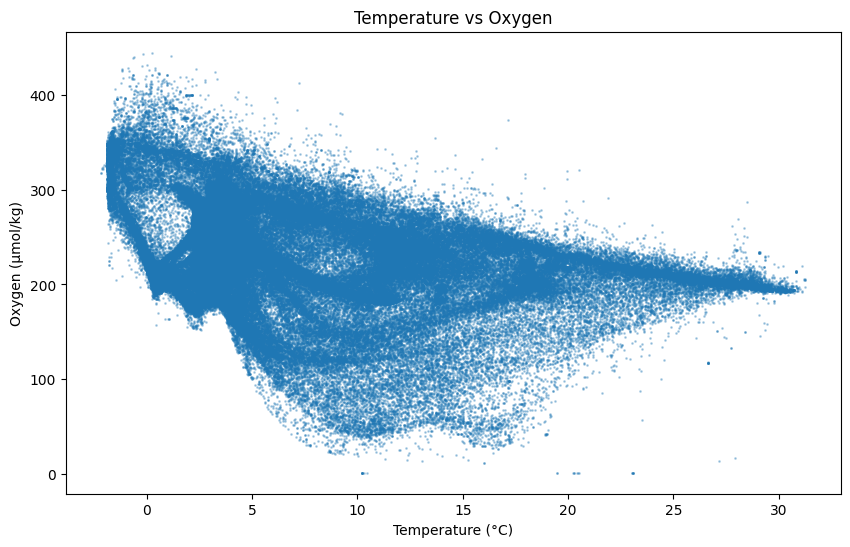

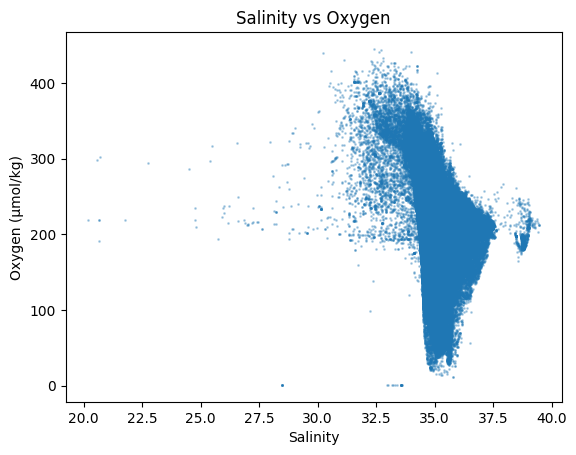

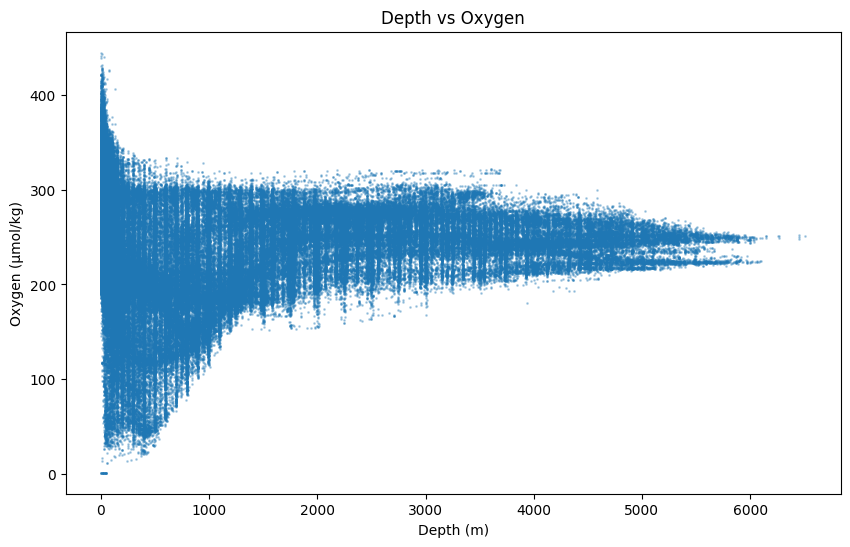

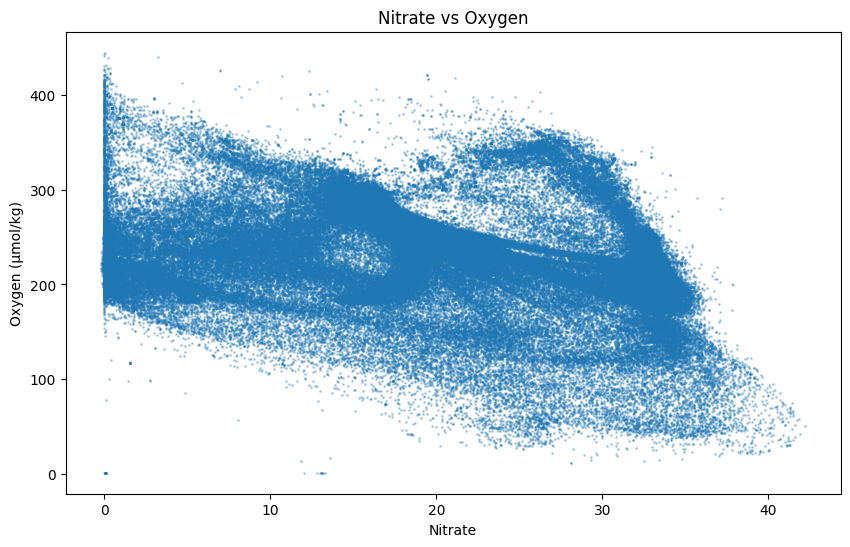

In [ ]:
# Exploring Relationships
#Create a scartter plot to see the relationships

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['G2temperature'], df_clean['G2oxygen'], alpha=0.3, s=1)
plt.xlabel('Temperature (°C)')
plt.ylabel('Oxygen (µmol/kg)')
plt.title('Temperature vs Oxygen')
plt.show()

plt.scatter(df_clean['G2salinity'], df_clean['G2oxygen'], alpha=0.3, s=1)
plt.xlabel('Salinity')
plt.ylabel('Oxygen (µmol/kg)')
plt.title('Salinity vs Oxygen')
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df_clean['G2depth'], df_clean['G2oxygen'], alpha=0.3, s=1)
plt.xlabel('Depth (m)')
plt.ylabel('Oxygen (µmol/kg)')
plt.title('Depth vs Oxygen')
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df_clean['G2nitrate'], df_clean['G2oxygen'],  alpha=0.3, s=1)
plt.xlabel('Nitrate')
plt.ylabel('Oxygen (µmol/kg)')
plt.title('Nitrate vs Oxygen')
plt.show()

In [ ]:
#Model selection important test
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

#Reasons as to why i've picked these models:
#A reason why i've chosen linear regression is due to it simplicity. It assumes a straight-line relationship between the inputs and oxygen. It's added first to create a test case, benchmark on everything after this model so i can see if its complex enough to beat this model.
#Ridge regression is quite similar to Linear Regression but it has a penalty that halts when any indivudal feature is dominating too much. Its included to see whether it could be further reined in to assist with my data
#Decision tree would split my dataset into branches for the purposes of capturing non-linear curved relationships which is great as linear models wouldn't be able to accomplish that. It's a relatively simple non-linear option
# Random Forrest regressor would be great since its a large amount of deicsion trees averaged together which signficantly reduces the amount of over fitting a single tree would suffer from. It's included since ensembles are great for generalising better and this was the top performer.
# Gradient boosting is great as it consists of a lot of trees that are built one after the other, ensuring corrections are made to the last one's mistakes and errors. Its a second ensemble apporach that different in order to compare against my random forest regressor.
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state = 42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

# Two different feature sets, one has 7 features while the other has 10.

features_full = [
    'G2temperature', 'G2salinity', 'G2depth','G2nitrate','G2phosphate', 'G2silicate', 'G2latitude','G2longitude', 'G2year','G2month'
    ]

features_basic = [
    'G2temperature', 'G2salinity', 'G2depth', 'G2latitude','G2longitude', 'G2year','G2month'
]

#Predictor, target
y = df_clean['G2oxygen']

#Testing: need to train on the earlier years then test on later years. We'll pick a cut off year. Everything before that year will be training, everything after is testing
#Year based split
cutoff = df_clean['G2year'].median()
print(f"Cutoff year: {cutoff}")


train_df = df_clean[df_clean['G2year'] <= cutoff]
test_df = df_clean[df_clean['G2year'] > cutoff]

print(f"Training rows (older years): {len(train_df)}")
print(f"Testing rows (newer years): {len(test_df)}")

#Evaluation function

def evaluate_models(features,label):
  results = {}

  X_train = train_df[features]
  y_train = train_df['G2oxygen']
  X_test = test_df[features]
  y_test = test_df['G2oxygen']

  print(f"\n=== {label} ===")

  for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}")

  return results

  #Running both feature sets through  2 models

results_full = evaluate_models(features_full, "FULL MODEL (Advanced)")
results_basic = evaluate_models(features_basic, "BASIC MODEL (No Nutrients)")



Cutoff year: 1998.0
Training rows (older years): 130677
Testing rows (newer years): 127280

=== FULL MODEL (Advanced) ===
Linear Regression: RMSE=24.68, MAE=18.28, R2=0.80
Ridge Regression: RMSE=24.68, MAE=18.28, R2=0.80
Decision Tree Regressor: RMSE=12.36, MAE=7.15, R2=0.95
Random Forest Regressor: RMSE=9.99, MAE=5.51, R2=0.97
Gradient Boosting Regressor: RMSE=12.41, MAE=8.02, R2=0.95

=== BASIC MODEL (No Nutrients) ===
Linear Regression: RMSE=49.22, MAE=33.78, R2=0.22
Ridge Regression: RMSE=49.22, MAE=33.78, R2=0.22
Decision Tree Regressor: RMSE=16.50, MAE=9.16, R2=0.91
Random Forest Regressor: RMSE=13.71, MAE=7.36, R2=0.94
Gradient Boosting Regressor: RMSE=21.64, MAE=13.06, R2=0.85


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

#Need to rebuild the year-based split but this time, per band analysis would need to be ran on year based split
cutoff = df_clean['G2year'].median()
train_df = df_clean[df_clean['G2year'] <= cutoff]
test_df = df_clean[df_clean['G2year'] > cutoff]

X_train = train_df[features_full]
y_train = train_df['G2oxygen']
X_test = test_df[features_full]
y_test = test_df['G2oxygen']



rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

bands = {
    'Hypoxic (<60)':  (y_test <60).values,
    'Low (60-120)' :  ((y_test >= 60) & (y_test < 120)).values,
    'Healthy (≥120)': (y_test >= 120).values,
}

print(f"{'Band': <20}{'n':>8}{'MAE': >10}{'RMSE':>10}")
for name, mask in bands.items():
  if mask.sum() > 0:
    mae = mean_absolute_error(y_test[mask], y_pred[mask])
    rmse = root_mean_squared_error(y_test[mask], y_pred[mask])
    print(f"{name:<20}{mask.sum():>8}{mae:>10.2f}{rmse:>10.2f}")


Band                       n       MAE      RMSE
Hypoxic (<60)           1375     19.33     37.05
Low (60-120)            3690      6.61     11.18
Healthy (≥120)        122215      5.32      9.21


In [ ]:
import sklearn; print(sklearn.__version__)

1.6.1


In [ ]:
from sklearn.model_selection import cross_val_score


#Weaker method, crossvalidation

X_full = df_clean[features_full]
y = df_clean['G2oxygen']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
cv = cross_val_score(rf, X_full, y , cv=5, scoring='r2')
print(f"CrossVal R2 (secondary check): {cv.mean():.3f}")

CrossVal R2 (secondary check): 0.975


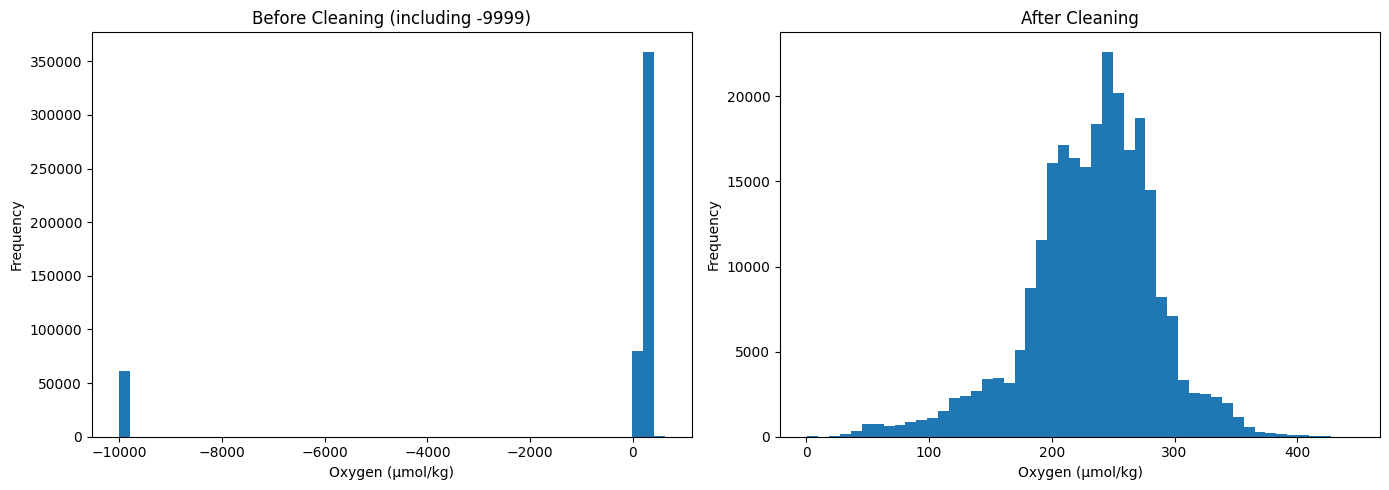

In [ ]:
#Oyxgen distribution before cleaning and after cleaning.

#Before Clean Up: Oxygen columns with the -9999 values still inside
oxygen_before = df['G2oxygen']
#After Clean Up: Oxygen from my cleaned dataframe
oxygen_after = df_clean['G2oxygen']
#Comparison of the Two Charts Side by Sid:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(oxygen_before, bins=50)
axes[0].set_xlabel('Oxygen (µmol/kg)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Before Cleaning (including -9999)')

axes[1].hist(oxygen_after, bins=50)
axes[1].set_xlabel('Oxygen (µmol/kg)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('After Cleaning')

plt.tight_layout()
plt.show()

#As you can see this visual contrast proves why the cleaning step was important in this notebook.

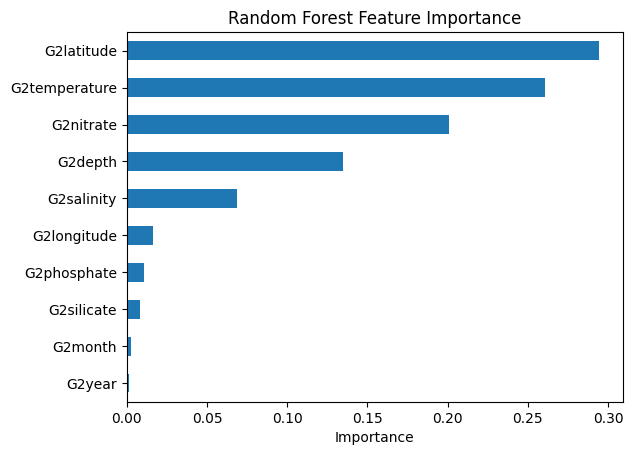

G2latitude       0.294375
G2temperature    0.260822
G2nitrate        0.200735
G2depth          0.134671
G2salinity       0.068908
G2longitude      0.016519
G2phosphate      0.011066
G2silicate       0.008537
G2month          0.002845
G2year           0.001522
dtype: float64


In [ ]:
#Feature importance checking:

#Needing to retrain the models due to the 'models' currently holding models trained on the 7 feature basic set. This would need ot be trained on 10
rf= RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df_clean[features_full], df_clean['G2oxygen'])

#feature_importances_ lines up with the columns in X, in order
importance = pd.Series(rf.feature_importances_, index=df_clean[features_full].columns)

#Sorting through and plotting via smallest to largest so the biggest bar is on top
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

print(importance.sort_values(ascending=False))


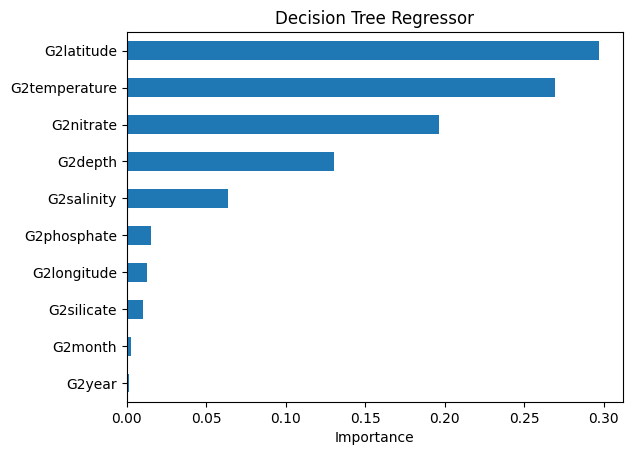

G2latitude       0.297064
G2temperature    0.269278
G2nitrate        0.196400
G2depth          0.130057
G2salinity       0.063926
G2phosphate      0.015437
G2longitude      0.012877
G2silicate       0.010502
G2month          0.002955
G2year           0.001505
dtype: float64


In [ ]:
#Feature importance checking :

#Needing to retrain the models due to the 'models' currently holding models trained on the 7 feature basic set. This would need ot be trained on 10
dt = DecisionTreeRegressor(random_state=42)
dt.fit(df_clean[features_full], df_clean['G2oxygen'])

#feature_importances_ lines up with the columns in X, in order
importance = pd.Series(dt.feature_importances_, index=df_clean[features_full].columns)

#Sorting through and plotting via smallest to largest so the biggest bar is on top
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Decision Tree Regressor')
plt.show()

print(importance.sort_values(ascending=False))


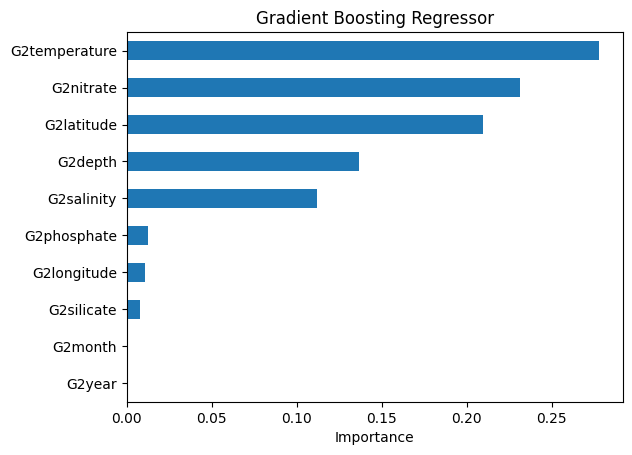

G2temperature    0.277974
G2nitrate        0.231220
G2latitude       0.209469
G2depth          0.136753
G2salinity       0.111746
G2phosphate      0.012690
G2longitude      0.010896
G2silicate       0.007765
G2month          0.001042
G2year           0.000443
dtype: float64


In [ ]:
#Feature importance checking:

#Needing to retrain the models due to the 'models' currently holding models trained on the 7 feature basic set. This would need ot be trained on 10
gb = GradientBoostingRegressor(random_state=42)
gb.fit(df_clean[features_full], df_clean['G2oxygen'])

#The established feature_importances_ would essentially, in order, line up with the columns in X.
importance = pd.Series(gb.feature_importances_, index=df_clean[features_full].columns)

#Sorting smallest to largest before plotting places the largest bar on top, with the rest descending
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Gradient Boosting Regressor')
plt.show()

print(importance.sort_values(ascending=False))


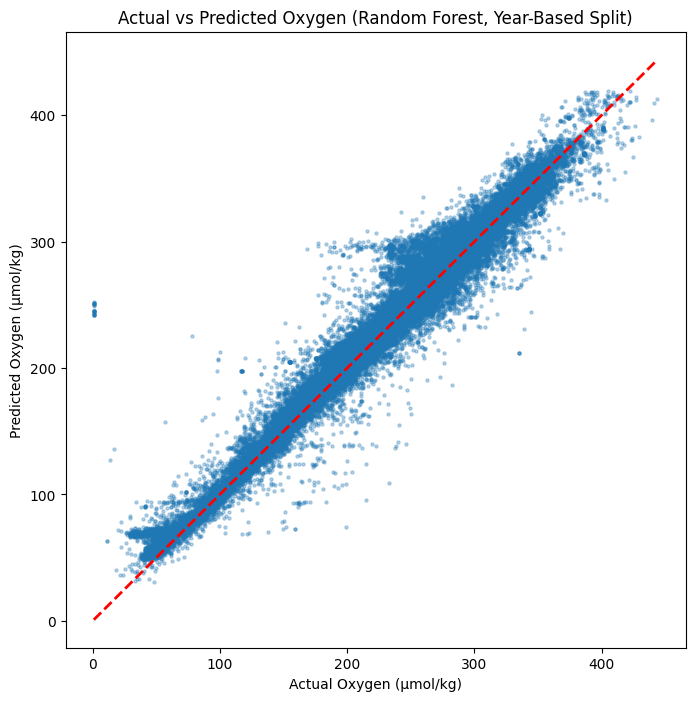

In [ ]:
#Recompute the pair to match to the random forest model
X_train = train_df[features_full]
y_train = train_df['G2oxygen']
X_test = test_df[features_full]
y_test = test_df['G2oxygen']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)



#Result visualisations
#Actual vs predicted oxygen for the best model on the year based test set
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)

#Perfect model would essentially put every point on this diagonal lines
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel('Actual Oxygen (µmol/kg)')
plt.ylabel('Predicted Oxygen (µmol/kg)')
plt.title('Actual vs Predicted Oxygen (Random Forest, Year-Based Split)')
plt.show()

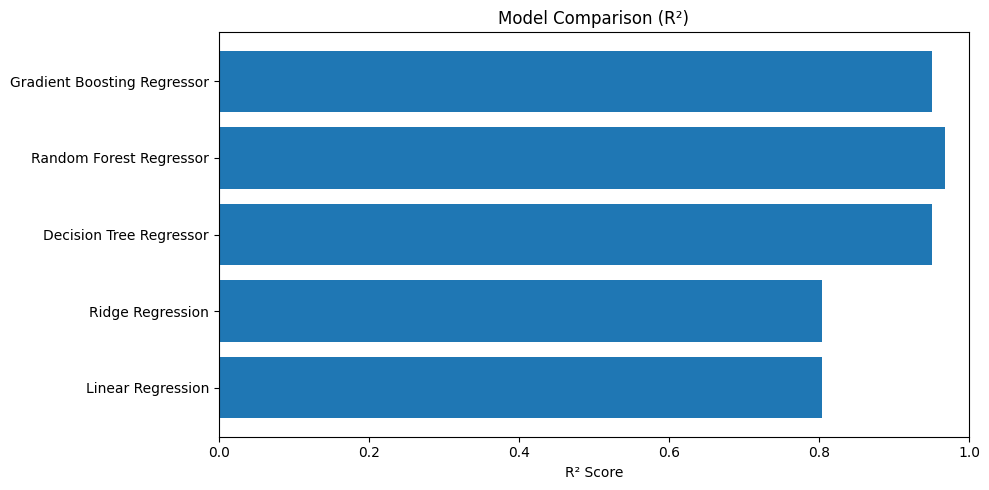

In [ ]:

#Bar chart comparison of R2 across all five models Full
model_names = list(results_full.keys())
r2_values = [results_full[n]['R2'] for n in model_names]

plt.figure(figsize=(10, 5))
plt.barh(model_names, r2_values)
plt.xlabel('R² Score')
plt.title('Model Comparison (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
#Saving the model so I can load it later using the dashboard. Retraining on the full fetures first just to make sure its the version i want the dashboard to server.

import joblib

rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_full, y)

joblib.dump(rf_full, 'DEOXY_rf_FULL_model.pkl')
print("Model saved as DEOXY_rf_Full_model.pkl")

In [ ]:
X_basic = df_clean[features_basic]

In [ ]:
 #Saving the model so I can load it later using the dashboard. Retraining on the full fetures first just to make sure its the version i want the dashboard to server.

import joblib

rf_basic = RandomForestRegressor(n_estimators=100, random_state=42)
rf_basic.fit(X_basic, y)

joblib.dump(rf_basic, 'DEOXY_rf_BASIC_model.pkl')
print("Model saved as DEOXY_rf_BASIC_model.pkl")

In [ ]:
#Residuals: exactly how far is each prediction off? (actual minus predicted)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha =0.3, s=5)

#In order to generate a perfect prediction with no error attached, a horizontal line through zero would be necessary.
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.xlabel('Predicted Oxygen (µmol/kg)')
plt.ylabel('Residual (Actual - Predicted)(µmol/kg)')
plt.title('Residual Plot)')
plt.show()

In [ ]:
import plotly.express as px
import plotly.io as pio

# Now all 5 models will be uused and their r2 scores as the same data as the matplotlib chart


model_names = list(results_full.keys())
r2_values = [results_full[n]['R2'] for n in model_names]

#Creating a horizontal bar chart thats interactive
fig = px.bar(
    x=r2_values,
    y=model_names,
    orientation='h',
    labels={'x': 'R² score', 'y': 'Model'},
    title='Model Comparison (R²)',
    range_x=[0, 1]
)

#Conversion: the chart will be transitioing to an html string for the purposes of being used in my Flask page.
chart_html = pio.to_html(fig, full_html=False)
print('Chart Built - ready for embedding.')

In [ ]:

import plotly.express as px

#My actual vs predicted oxygen
fig = px.scatter(x=y_test, y=y_pred,
                 labels={'x':'Actual Oxygen (µmol/kg)',
                         'y':'Predicted Oxygen (µmol/kg)'},
                 title='Actual vs Predicted Oxygen (Random Forest)',
                 opacity=0.3)
#Diagonal Line of perfect prediction added
fig.add_shape(type='line',
              x0=y_test.min(), y0=y_test.min(),
              x1=y_test.max(), y1=y_test.max(),
              line=dict(color='red', dash='dash'))

#saving html file
fig.write_html('actual_vs_predicted.html')
print('saved actual_vs_predicted.html')



In [ ]:
import joblib

#T8

#Start loading the basic model
model_basic = joblib.load('DEOXY_rf_BASIC_model.pkl')

#The same seven inputs will be inputted, as well as the same order as training, starting from temperature to salinity, depth, latitude,longitude, year and month

test_input = [[8, 35, 50, 45, -30, 2015, 6]]
print("Basic model prediction:", model_basic.predict(test_input))

FileNotFoundError: [Errno 2] No such file or directory: 'DEOXY_rf_BASIC_model.pkl'

In [ ]:
import joblib

#T8

#Start loading the full model
model_full = joblib.load('DEOXY_rf_FULL_model.pkl')

#Now the full 10 inputs will be entered, as well as the same order as training, starting from temperature to salinity, Depth, Nitrate, Phosphate, Silicate,  latitude,longitude, year and month

test_input_full = [[8, 35, 50, 15, 1.2, 20, 45, -30, 2015, 6]]
print("Full model prediction:", model_full.predict(test_input_full))

Full model prediction: [226.1065]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
